# Figure — Vigor Time Courses

Three-panel figure showing encounter-aligned vigor dynamics:
- **A** Vigor by threat level around encounter
- **B** Attack vs non-attack at high threat
- **C** Effort reallocation pattern (threat x choice)

In [1]:
import sys, warnings
sys.path.insert(0, '/workspace/scripts/plotting')
sys.path.insert(0, '/workspace/scripts')
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from plotter import Colors, set_plot_style, style_axis

set_plot_style()

## 1. Load and prepare data

In [2]:
# ── Load vigor time series ─────────────────────────────────────────────────
ts = pd.read_parquet('/workspace/data/exploratory_350/processed/vigor_processed/smoothed_vigor_ts.parquet')

# ── Identify and remove probe trials ──────────────────────────────────────
feelings = pd.read_csv(
    '/workspace/data/exploratory_350/processed/stage5_filtered_data_20260320_191950/feelings.csv'
)
probe_pairs = feelings[['subj', 'trialNumber']].drop_duplicates()
probe_pairs = probe_pairs.rename(columns={'trialNumber': 'trial'})
probe_pairs['is_probe'] = True

ts = ts.merge(probe_pairs, on=['subj', 'trial'], how='left')
ts = ts[ts['is_probe'] != True].drop(columns='is_probe')

print(f"After removing probes: {len(ts):,} rows, "
      f"{ts.groupby('subj')['trial'].nunique().mean():.1f} trials/subj")

# ── Encounter-aligned time ────────────────────────────────────────────────
ts['t_enc'] = ts['t'] - ts['encounterTime']
print(f"Threat levels: {sorted(ts['threat'].unique())}")
print(f"Choice values: {sorted(ts['choice'].unique())}")
print(f"N subjects: {ts['subj'].nunique()}")

After removing probes: 2,081,800 rows, 44.7 trials/subj
Threat levels: [np.float64(0.1), np.float64(0.5), np.float64(0.9)]
Choice values: [np.int64(0), np.int64(1)]
N subjects: 293


## 2. Prepare binned encounter-aligned data

In [3]:
# ── Compute excess effort = vigor_norm - effort_chosen ────────────────
# This removes the demand confound (choice composition changes with threat)
ts['effort_chosen'] = np.where(ts['choice'] == 1, ts['effort_H'], 0.4)
ts['excess'] = ts['vigor_norm'] - ts['effort_chosen']
ts['t_end'] = ts['t'] - ts['trialEndTime']

# ── Bin encounter-aligned time at 0.1s resolution ─────────────────────────
WIN_LO, WIN_HI, BIN_SIZE = -2.0, 4.0, 0.1

ts_win = ts[(ts['t_enc'] >= WIN_LO) & (ts['t_enc'] <= WIN_HI)].copy()
ts_win['t_bin'] = (ts_win['t_enc'] / BIN_SIZE).round() * BIN_SIZE
ts_win['t_bin'] = ts_win['t_bin'].round(2)

print(f"Rows in window: {len(ts_win):,}")

# ── Panel A data: ONSET period excess effort by threat (trial-start aligned) ──
ts_onset = ts[(ts['t'] >= 0) & (ts['t'] <= 2.5)].copy()
ts_onset['t_bin'] = (ts_onset['t'] / BIN_SIZE).round() * BIN_SIZE
ts_onset['t_bin'] = ts_onset['t_bin'].round(2)

subj_onset = (
    ts_onset
    .groupby(['subj', 'threat', 't_bin'])['excess']
    .mean()
    .reset_index()
)

panel_a = (
    subj_onset
    .groupby(['threat', 't_bin'])['excess']
    .agg(['mean', 'sem'])
    .reset_index()
)
print(f"\nPanel A (onset): {len(panel_a)} rows")

# ── Panel B data: Attack − Non-attack DIFFERENCE in excess effort ────────
subj_atk_bin = (
    ts_win
    .groupby(['subj', 'isAttackTrial', 't_bin'])['excess']
    .mean()
    .reset_index()
)

# Pivot to get per-subject difference
_att = subj_atk_bin[subj_atk_bin['isAttackTrial']==1].rename(columns={'excess':'att'}).drop(columns='isAttackTrial')
_non = subj_atk_bin[subj_atk_bin['isAttackTrial']==0].rename(columns={'excess':'non'}).drop(columns='isAttackTrial')
_diff = _att.merge(_non, on=['subj','t_bin'])
_diff['attack_effect'] = _diff['att'] - _diff['non']

panel_b = _diff.groupby('t_bin')['attack_effect'].agg(['mean','sem']).reset_index()
print(f"Panel B (difference): {len(panel_b)} rows")
print(f"  Peak diff at t={panel_b.loc[panel_b['mean'].idxmax(), 't_bin']:.1f}s: {panel_b['mean'].max():.4f}")

# ── Panel C data: Terminal attack effect by HIGH vs LOW δ ────────────────
import os, sys
params_v = pd.read_csv('/workspace/results/stats/mcmc_vigor_params.csv')
ts = ts.merge(params_v[['subj','delta_mcmc']], on='subj', how='left')
delta_median = ts.groupby('subj')['delta_mcmc'].first().median()
ts['delta_group'] = np.where(ts['delta_mcmc'] >= delta_median, 'High', 'Low')

ts_term = ts[(ts['t_end'] >= -3.0) & (ts['t_end'] <= -0.5)].copy()
ts_term['t_bin'] = (ts_term['t_end'] / BIN_SIZE).round() * BIN_SIZE
ts_term['t_bin'] = ts_term['t_bin'].round(2)

# Per subject × delta_group × attack × time bin
subj_term = (
    ts_term
    .groupby(['subj', 'delta_group', 'isAttackTrial', 't_bin'])['excess']
    .mean()
    .reset_index()
)

panel_c = (
    subj_term
    .groupby(['delta_group', 'isAttackTrial', 't_bin'])['excess']
    .agg(['mean', 'sem'])
    .reset_index()
)
print(f"Panel C (terminal by δ × attack): {len(panel_c)} rows")

Rows in window: 1,321,987

Panel A (onset): 78 rows
Panel B (difference): 61 rows
  Peak diff at t=1.9s: 0.1271


Panel C (terminal by δ × attack): 104 rows


## 3. Figure — Vigor time courses (3 panels)

Saved to results/figs/paper/fig_vigor_timecourse.{pdf,png}


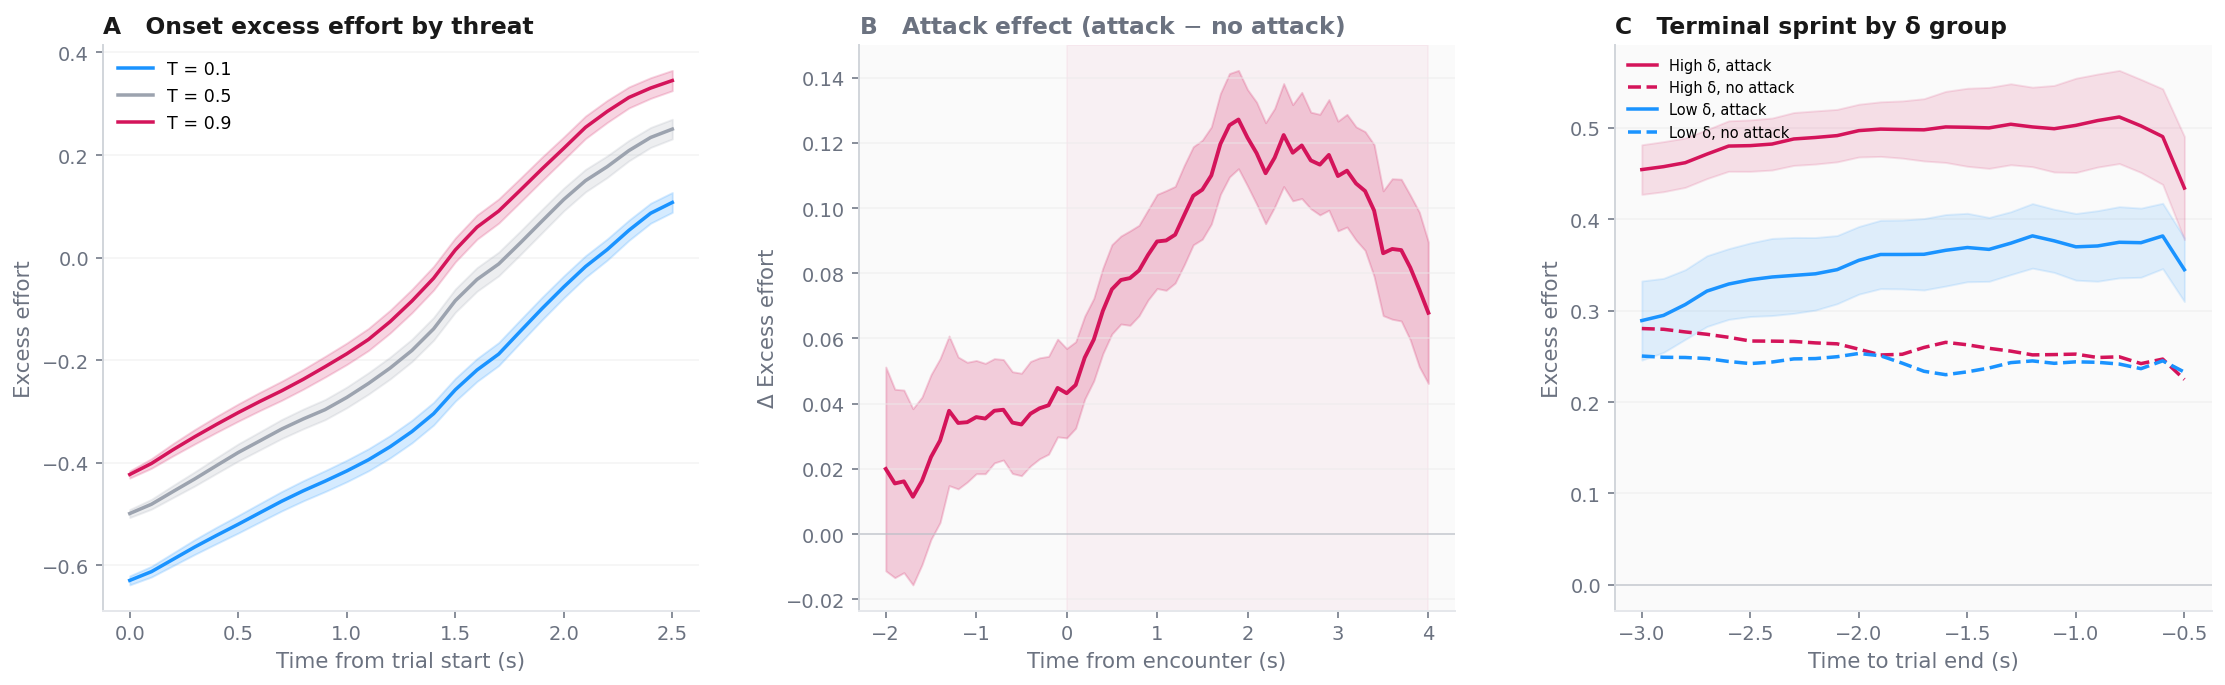

In [4]:
# ══════════════════════════════════════════════════════════════════════════
# FIGURE — Vigor Time Courses (3 panels)
# ══════════════════════════════════════════════════════════════════════════

THREAT_COLORS = {0.1: Colors.CERULEAN2, 0.5: Colors.SLATE, 0.9: Colors.RUBY1}
THREAT_LABELS = {0.1: 'T = 0.1', 0.5: 'T = 0.5', 0.9: 'T = 0.9'}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── Panel A: Encounter-aligned vigor by threat level ──────────────────────
ax = axes[0]
for threat_val in [0.1, 0.5, 0.9]:
    d = panel_a[panel_a['threat'] == threat_val].sort_values('t_bin')
    ax.plot(d['t_bin'], d['mean'], color=THREAT_COLORS[threat_val],
            linewidth=1.8, label=THREAT_LABELS[threat_val], zorder=3)
    ax.fill_between(d['t_bin'],
                    d['mean'] - d['sem'],
                    d['mean'] + d['sem'],
                    color=THREAT_COLORS[threat_val], alpha=0.18, zorder=2)

# Panel A: onset-aligned, no encounter line needed
ax.legend(fontsize=9, frameon=False, loc='upper left')
ax.set_title('A   Onset excess effort by threat', fontsize=12, fontweight='bold',
             color=Colors.DARK_GREY, loc='left')
style_axis(ax, ylabel='Excess effort',
           xlabel='Time from trial start (s)')

# ── Panel B: Attack effect (difference) ───────────────────────────────
ax = axes[1]
ax.set_facecolor('#fafafa')
# onset: no encounter line
ax.axhline(0, color='#9ca3af', ls='-', lw=0.8, alpha=0.5)

pb = panel_b.sort_values('t_bin')
ax.plot(pb['t_bin'], pb['mean'], color=Colors.RUBY1, lw=2)
ax.fill_between(pb['t_bin'],
                pb['mean'] - 1.96 * pb['sem'],
                pb['mean'] + 1.96 * pb['sem'],
                color=Colors.RUBY1, alpha=0.2)
ax.axvspan(0, 4, color=Colors.RUBY1, alpha=0.04)
ax.set_title('B   Attack effect (attack $-$ no attack)', fontsize=12, fontweight='bold',
             color=Colors.INK, loc='left')
style_axis(ax, ylabel='$\\Delta$ Excess effort',
           xlabel='Time from encounter (s)')

# ── Panel C: Terminal attack effect by δ group ────────────────────────
ax = axes[2]
ax.set_facecolor('#fafafa')
ax.axhline(0, color='#9ca3af', ls='-', lw=0.8, alpha=0.5)

line_styles = {
    ('High', 1): (Colors.RUBY1, '-', 'High δ, attack'),
    ('High', 0): (Colors.RUBY1, '--', 'High δ, no attack'),
    ('Low', 1): (Colors.CERULEAN2, '-', 'Low δ, attack'),
    ('Low', 0): (Colors.CERULEAN2, '--', 'Low δ, no attack'),
}

for (dg, att), (color, ls, label) in line_styles.items():
    d = panel_c[(panel_c['delta_group']==dg) & (panel_c['isAttackTrial']==att)].sort_values('t_bin')
    ax.plot(d['t_bin'], d['mean'], color=color, ls=ls, lw=1.8, label=label, zorder=3)
    if ls == '-':  # only shade attack lines
        ax.fill_between(d['t_bin'], d['mean']-1.96*d['sem'], d['mean']+1.96*d['sem'],
                        color=color, alpha=0.12, zorder=2)

ax.legend(fontsize=7.5, frameon=False, loc='upper left', ncol=1)
ax.set_title('C   Terminal sprint by δ group', fontsize=12, fontweight='bold',
             color=Colors.DARK_GREY, loc='left')
style_axis(ax, ylabel='Excess effort',
           xlabel='Time to trial end (s)')

fig.tight_layout(w_pad=3.0)

import os
os.makedirs('/workspace/results/figs/paper', exist_ok=True)
fig.savefig('/workspace/results/figs/paper/fig_vigor_timecourse.pdf',
            bbox_inches='tight', dpi=300)
fig.savefig('/workspace/results/figs/paper/fig_vigor_timecourse.png',
            bbox_inches='tight', dpi=300)
print("Saved to results/figs/paper/fig_vigor_timecourse.{pdf,png}")
plt.show()